# INSTALL DEPENDENCIES

In [1]:
INITAL_SETUP = True

if INITAL_SETUP:
    %pip install fastkaggle
    %pip install kaggle
    %pip install dotenv
    %pip install ipdb
    %pip install fastai
    %pip install timm
    %pip install -Uqq ddgs fastai
    %pip uninstall -y fastprogress
    %pip install "fastprogress==1.0.3"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 14.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Found existing installation: fastprogress 1.1.3
Uninstalling fastprogress-1.1.3:
  Successfully uninstalled fastprogress-1.1.3
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import fastkaggle
import pandas as pd
import numpy as np
from pathlib import Path
import shutil
import os
from fastai.tabular import *
from fastai.tabular.all import *
from fastai.vision.all import *
import timm

PATH_LOCAL_PATH_DATA_STORAGE = Path(r'D:\kaggle_data')
COMPETITION_NAME = '104-flowers-garden-of-eden'


# CHECK IF RUNNING ON KAGGLE OR ELSEWHERE

In [3]:
'Kaggle' if fastkaggle.iskaggle else 'Not Kaggle'

'Kaggle'

In [4]:
import torch
import fastai
print(torch.__version__)
print(fastai.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.9.0+cu126
2.8.7
True
Tesla P100-PCIE-16GB


# PREPARE KAGGLE DATA

In [5]:
FORMAT_SIZE = "jpeg-224x224"

if fastkaggle.iskaggle:
    #path = os.path.join(Path('../input'), COMPETITION_NAME) # generates path containing competition name
    #for dirname, _, filenames in os.walk('/kaggle/input'):
    #    for filename in filenames:
            #print(os.path.join(dirname, filename))
    #        pass
    path = os.path.join('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden',
                       FORMAT_SIZE) # generates path containing competition name
    
else:
    path = os.path.join(Path(PATH_LOCAL_PATH_DATA_STORAGE), COMPETITION_NAME) # generates path containing competition name
    path = os.path.join(path, 'versions', '1', FORMAT_SIZE) # generates path containing competition name

path
    


'/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224'

In [6]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("msheriey/104-flowers-garden-of-eden")

# print("Path to dataset files:", path)

Check to see if any images are broken and cannot be opened. 

In [7]:
CHECK_FOR_BROKEN_IMAGINES = False

if CHECK_FOR_BROKEN_IMAGINES:
    failed_train = verify_images(get_image_files(os.path.join(path,'train')))
    print(f"Number of broken images for train: {len(failed_train)}")
    for f in failed_train:
        print(f)

    failed_val = verify_images(get_image_files(os.path.join(path,'val')))
    print(f"Number of broken images for validiation: {len(failed_val)}")
    for f in failed_val:
        print(f)

    failed_test = verify_images(get_image_files(os.path.join(path,'test')))
    print(f"Number of broken images for test: {len(failed_test)}")
    for f in failed_test:
        print(f)

# Check out the images

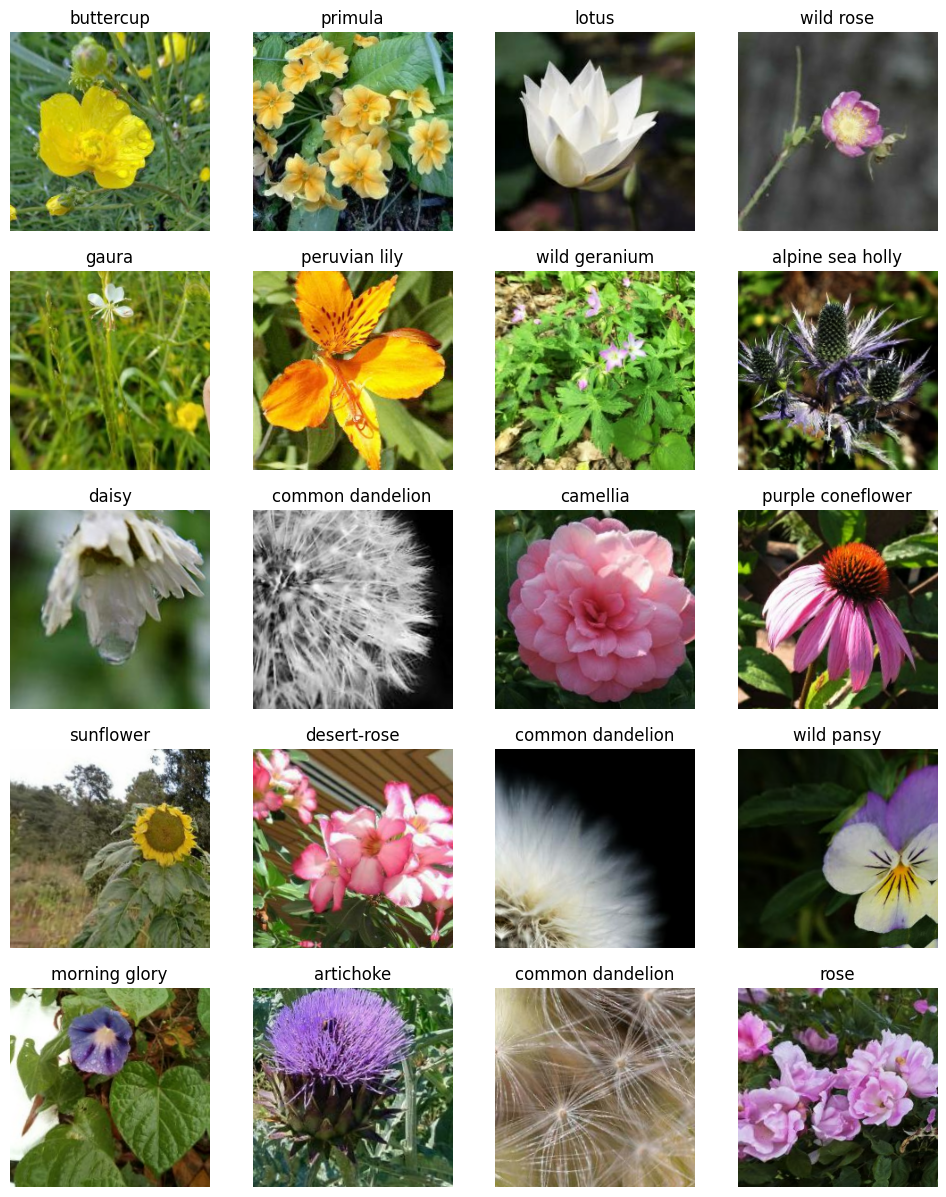

In [8]:
dls = ImageDataLoaders.from_folder(
    path,                                # path to images 
    train='train',
    valid='val',
    blocks = (ImageBlock, CategoryBlock),       # specify the type of data
    seed = 42,                           # random seed
    get_y = parent_label,
    item_tfms = Resize(224), # transform the images to 224x224
    batch_tfms=aug_transforms())   # provides a pre-configured, best-practice set of transformations (flips, rotations, zooms, 
                            #brightness changes, warping) with a 75% probability of application.          

dls.show_batch(max_n=20, nrows=5)

In [9]:
for vocab in dls.vocab:
    print(vocab)

alpine sea holly
anthurium
artichoke
azalea
balloon flower
barberton daisy
bee balm
bird of paradise
bishop of llandaff
black-eyed susan
blackberry lily
blanket flower
bolero deep blue
bougainvillea
bromelia
buttercup
californian poppy
camellia
canna lily
canterbury bells
cape flower
carnation
cautleya spicata
clematis
colt's foot
columbine
common dandelion
common tulip
corn poppy
cosmos
cyclamen 
daffodil
daisy
desert-rose
fire lily
foxglove
frangipani
fritillary
garden phlox
gaura
gazania
geranium
giant white arum lily
globe thistle
globe-flower
grape hyacinth
great masterwort
hard-leaved pocket orchid
hibiscus
hippeastrum 
iris
japanese anemone
king protea
lenten rose
lilac hibiscus
lotus
love in the mist
magnolia
mallow
marigold
mexican petunia
monkshood
moon orchid
morning glory
orange dahlia
osteospermum
passion flower
peruvian lily
petunia
pincushion flower
pink primrose
pink quill
pink-yellow dahlia
poinsettia
primula
prince of wales feathers
purple coneflower
red ginger
rose
r

# Vision Learner

In [10]:
learn = vision_learner(dls, 
                       convnext_tiny, #resnet18,
                       weights=ConvNeXt_Tiny_Weights.DEFAULT,
                       model_dir='/kaggle/working',
                       metrics=[accuracy, error_rate]).to_fp16()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 247MB/s] 


# Fine Tune
We fine tune this model because we want to take advantage of the pretrained model. This will sever the head and retrain the last layer for our specific application. 

In [11]:
#lrs = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

The next line is not necessary for training but does help ensure that the progress bar continues moving. This problem only exists when the python code is executing in Visual Studio Code. 

In [12]:
if 'TERM_PROGRAM' in os.environ.keys() and os.environ['TERM_PROGRAM'] == 'vscode':
    print("Running in VS Code")
    from IPython.display import clear_output, DisplayHandle
    def update_patch(self, obj):
        clear_output(wait=True)
        self.display(obj)
    DisplayHandle.update = update_patch

In [13]:
learn.fine_tune(3, base_lr = 0.0006918309954926372 )

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,3.107974,1.508320,0.633890,0.366110,04:18


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.751927,1.036986,0.740571,0.259429,04:51
1,1.253739,0.758725,0.805226,0.194774,04:49
2,1.065234,0.716771,0.814116,0.185884,04:49


# Quick check of the results

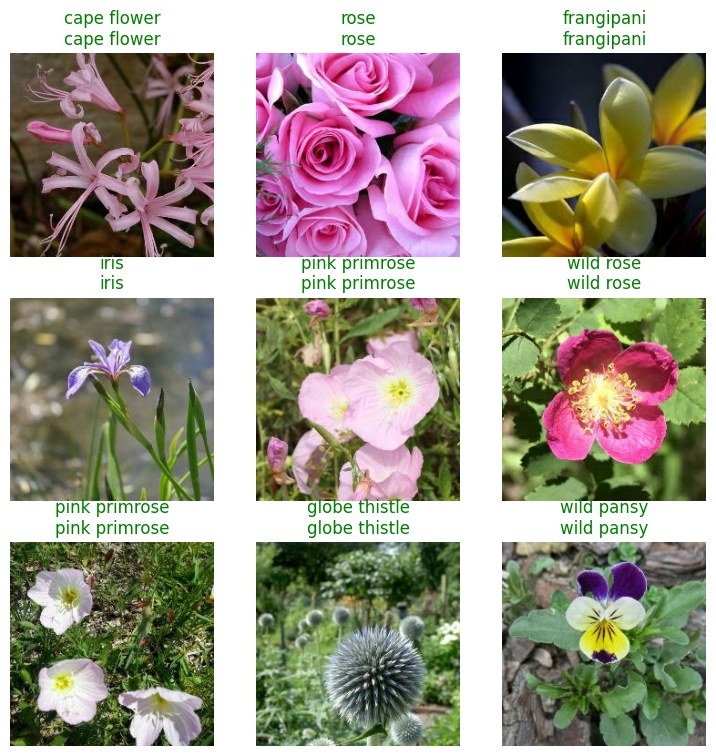

In [14]:
learn.show_results()

# Save model weights and state

In [15]:
learn.save('trained')

Path('/kaggle/working/trained.pth')

# Cleanup dataset

In [16]:
interp = ClassificationInterpretation.from_learner(learn)


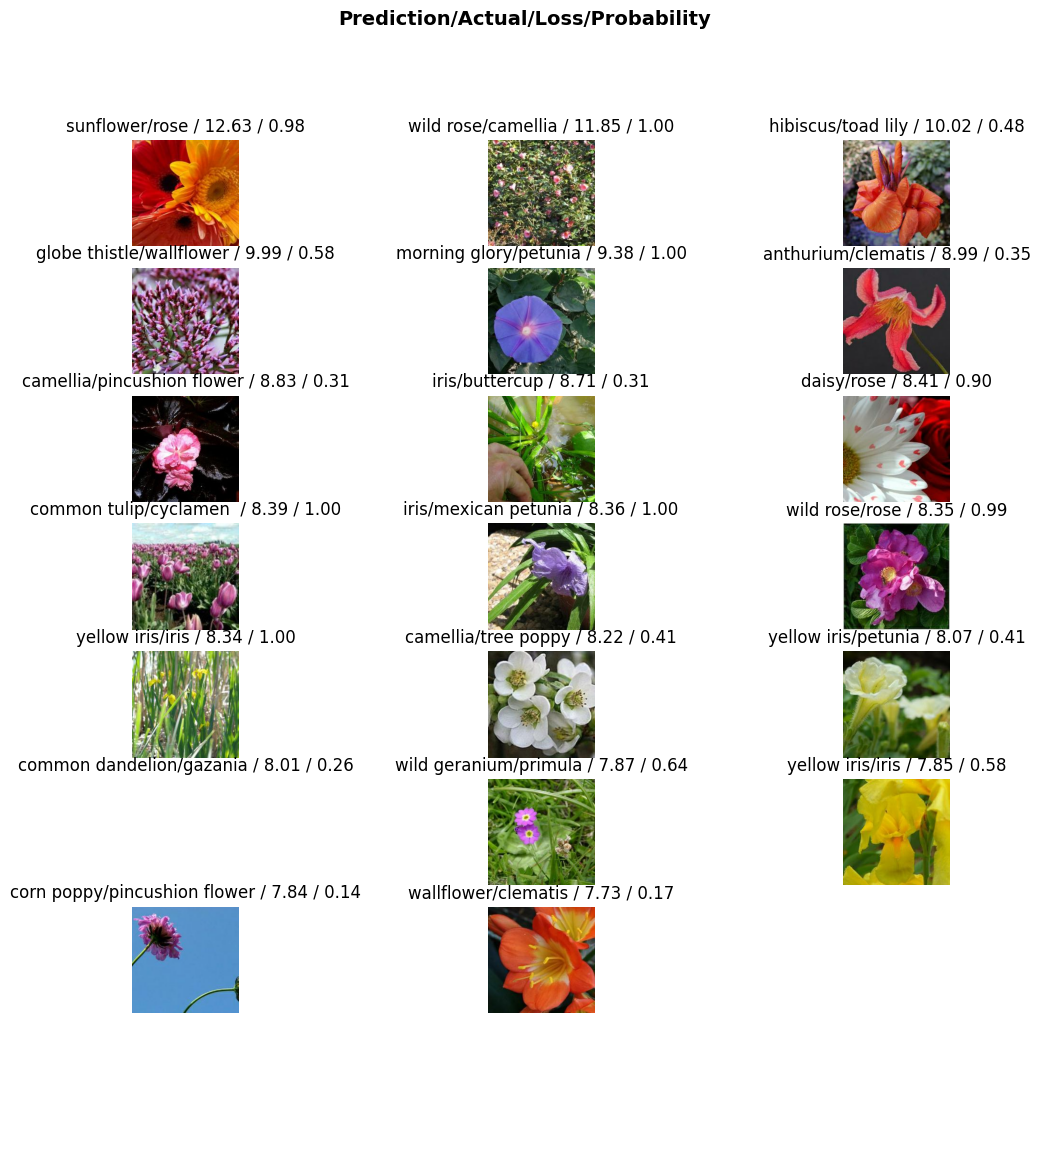

In [17]:
interp.plot_top_losses(20, figsize=((13,13)), nrows=8)

In [18]:
#class_report = interp.print_classification_report()
#class_report.sort_values('f1-score', axis='columns')

In [19]:
#from fastai.vision.widgets import *
#cleaner = ImageClassifierCleaner(learn)
#cleaner

In [20]:
## Delete images selected for deletion.
#for index in cleaner.delete():
#    cleaner.fns[index].unlink()

## Relabel images selected for relabeling.
#for index, category in cleaner.change():
#    shutil.move(str(cleaner.fns[index]), path/category)

# Prepare testing data

Load testing data....

In [21]:
test_files = get_image_files(os.path.join(path,'test'))
print("Found {} test files.".format(len(test_files)))

Found 7382 test files.


In [22]:
dls_test = learn.dls.test_dl(test_files)

# Inference

In [23]:
preds, _, decoded = learn.get_preds(dl=dls_test, with_decoded=True)

Let's check the results

In [24]:
preds, decoded
predicted_classes = [learn.dls.vocab[i] for i in preds.argmax(dim=1)]
len(predicted_classes)
print('Length of preds:', len(preds))
print('Length of decoded:', len(decoded))
print('Length of predicted_classes:', len(predicted_classes))


Length of preds: 7382
Length of decoded: 7382
Length of predicted_classes: 7382


In [25]:
predicted_classes[:10]


['wild rose',
 'iris',
 'rose',
 'moon orchid',
 'cosmos',
 'wild rose',
 'artichoke',
 'wild geranium',
 'wild rose',
 'iris']

In [26]:
#learn.show_results(dl=dls_test, max_n=5)
#interp = Interpretation.from_learner(learn, dl=dls_test)
#interp.plot_top_losses(9)
#learn.dls.show_results(dls_test.one_batch(), preds, max_n=9)

In [27]:
predicted_classes[0]

'wild rose'

In [28]:
if fastkaggle.iskaggle:
    path_submission = '/kaggle/input/competitions/tpu-getting-started/sample_submission.csv'
else:
    path_submission = os.path.join(path, '..', 'sample_submission.csv')

submission_csv = pd.read_csv(path_submission, header=0)
submission_csv.head(10)


,id,label
0,b48c962e0,0
1,a13d3dfa4,0
2,94269c190,0
3,bcb18c6e4,0
4,d15a4d94c,0
5,914b0e71b,0
6,065c9b5be,0
7,dd8b1aaca,0
8,8c39d1b41,0
9,e2fdce920,0


# Adding predictions to the submission CSV 

In [29]:
dls_test.items[:10]

[Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/1461713ad.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/3a1d5b5db.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/24aae97eb.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/5e2692d15.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/ce6f860f1.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/f67596886.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/aab3a2289.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/4fdd76274.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/test/3aa882bbe.jpeg'),
 Path('/kaggle/input/datasets/msheriey/104-flowers-garden-of-eden/jpeg-224x224/tes

In [30]:
# Get the original filenames/paths
file_names = [f.name.replace('.jpeg', '') for f in dls_test.items]
file_names[:10]

['1461713ad',
 '3a1d5b5db',
 '24aae97eb',
 '5e2692d15',
 'ce6f860f1',
 'f67596886',
 'aab3a2289',
 '4fdd76274',
 '3aa882bbe',
 'df5a78c3d']

In [31]:
# Combine them into a dictionary or list for easy viewing
results = list(zip(file_names, predicted_classes))
results[:10]
d_results = dict(results)

In [32]:
print(submission_csv.loc[0, 'id'] )
print(submission_csv.loc[0, 'label'] )

b48c962e0
0


In [33]:
submission_csv['label'] = submission_csv['label'].astype(str)

for index, row in submission_csv.iterrows():
    #print('index', index)
    #print('row id', row['id'])
    #print('row label', row['label'])
    matched_index = d_results.get(row['id'])
    #print('new label', matched_index)
    submission_csv.loc[index, 'label'] = matched_index
    #print('row label after', row['label'])
    # if index>10:
    #     break'

In [34]:
submission_csv.head(10)

,id,label
0,b48c962e0,corn poppy
1,a13d3dfa4,petunia
2,94269c190,rose
3,bcb18c6e4,wild rose
4,d15a4d94c,common dandelion
5,914b0e71b,wild rose
6,065c9b5be,pink-yellow dahlia
7,dd8b1aaca,watercress
8,8c39d1b41,cosmos
9,e2fdce920,wild geranium


Need to have numbers representing the labels, and not the names of the flowers themselves

In [35]:
# CLASSES from https://www.kaggle.com/ryanholbrook/petal-helper
CLASSES = ['pink primrose',    'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',     'wild geranium',     'tiger lily',           'moon orchid',              'bird of paradise', 'monkshood',        'globe thistle',         # 00 - 09
           'snapdragon',       "colt's foot",               'king protea',      'spear thistle', 'yellow iris',       'globe-flower',         'purple coneflower',        'peruvian lily',    'balloon flower',   'giant white arum lily', # 10 - 19
           'fire lily',        'pincushion flower',         'fritillary',       'red ginger',    'grape hyacinth',    'corn poppy',           'prince of wales feathers', 'stemless gentian', 'artichoke',        'sweet william',         # 20 - 29
           'carnation',        'garden phlox',              'love in the mist', 'cosmos',        'alpine sea holly',  'ruby-lipped cattleya', 'cape flower',              'great masterwort', 'siam tulip',       'lenten rose',           # 30 - 39
           'barberton daisy',  'daffodil',                  'sword lily',       'poinsettia',    'bolero deep blue',  'wallflower',           'marigold',                 'buttercup',        'daisy',            'common dandelion',      # 40 - 49
           'petunia',          'wild pansy',                'primula',          'sunflower',     'lilac hibiscus',    'bishop of llandaff',   'gaura',                    'geranium',         'orange dahlia',    'pink-yellow dahlia',    # 50 - 59
           'cautleya spicata', 'japanese anemone',          'black-eyed susan', 'silverbush',    'californian poppy', 'osteospermum',         'spring crocus',            'iris',             'windflower',       'tree poppy',            # 60 - 69
           'gazania',          'azalea',                    'water lily',       'rose',          'thorn apple',       'morning glory',        'passion flower',           'lotus',            'toad lily',        'anthurium',             # 70 - 79
           'frangipani',       'clematis',                  'hibiscus',         'columbine',     'desert-rose',       'tree mallow',          'magnolia',                 'cyclamen ',        'watercress',       'canna lily',            # 80 - 89
           'hippeastrum ',     'bee balm',                  'pink quill',       'foxglove',      'bougainvillea',     'camellia',             'mallow',                   'mexican petunia',  'bromelia',         'blanket flower',        # 90 - 99
           'trumpet creeper',  'blackberry lily',           'common tulip',     'wild rose']                                                                                                                                               # 100 - 103

CLASS_NUMS = list(range(len(CLASSES)))
class_converter = dict(zip(CLASSES, CLASS_NUMS))

In [36]:
def convert_class_to_num(flower_class):
    flower_number = class_converter.get(flower_class)
    return flower_number 
    
submission_csv['label'] = submission_csv['label'].apply(convert_class_to_num)

In [37]:
submission_csv.to_csv('submission.csv', index=False)